In [ ]:
# !pip install -qq langchain langchain-community langchain_openai pymupdf tiktoken faiss-cpu python-dotenv langchain-text-splitters

: 

In [ ]:
# !pip install -qq langchain-core langchain_nvidia_ai_endpoints gradio fastapi langserve

add paper: Knowledge-guided Machine Learning: Current Trends and Future Prospects
other papers in the NC paper

example questions: explain to me what KGML is like I'm a 5 years old; can you walk me through the steps of a KGML model development

In [1]:
# Mount Google Drive to access files from your Drive
from google.colab import drive
drive.mount('/content/drive/')

import sys
# Project directory where the PyKGML files are stored
base_path = '/content/drive/MyDrive/Colab Notebooks/RAG/NVIDIA course-RAG with LLMs/'
# Add the project directory to Python's module search path
sys.path.append(base_path)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
import os
import re
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import (
    TextLoader, # for .py, .txt, .md
    NotebookLoader,   # for .ipynb
)

def load_pdfs(folder_path):
    docs = []

    for file in os.listdir(folder_path):
        if file.endswith(".pdf"):
            loader = PyMuPDFLoader(os.path.join(folder_path, file))
            docs.extend(loader.load())
    return docs


def load_source_files(folder_path):
    docs = []

    for root, _, files in os.walk(folder_path):
        for file in files:
            full_path = os.path.join(root, file)

            # Python
            if file.endswith(".py"):
                loader = TextLoader(full_path, encoding="utf-8")

            # Notebooks
            elif file.endswith(".ipynb"):
                loader = NotebookLoader(full_path)

            # Markdown & txt → use TextLoader (simple and reliable)
            elif file.endswith(".md") or file.endswith(".txt"):
                loader = TextLoader(full_path, encoding="utf-8")

            else:
                continue

            docs.extend(loader.load())

    return docs



pdf_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=150,
    separators=["\n\n", "\n", ".", ";", ",", " "],
)

code_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=100,
    separators=["\nclass ", "\ndef ", "\n# ", "\n\n", "\n", " ", ""],
)


def is_reference_chunk(text):
    """Return True if the chunk is likely references-only."""
    text_lower = text.lower().strip()

    # If it starts with "references" or "bibliography"
    if text_lower.startswith(("references", "bibliography")):
        return True

    # Contains many numbered citation patterns like: [1], [2], [3]...
    if len(re.findall(r"\[\d+\]", text)) >= 3:
        return True

    # If >70% of lines look like citations
    lines = text.split("\n")
    citation_lines = sum(
        bool(re.match(r"^\s*\[\d+\]", ln)) or  # [12] citation
        bool(re.match(r"^\s*\d+\.\s", ln)) or  # numbered list like "12. Author..."
        "doi" in ln.lower()
        for ln in lines
    )
    if len(lines) > 0 and citation_lines / len(lines) > 0.5:
        return True

    return False

In [4]:
# load documents as chunks
doc_path = base_path + 'RAG documents/'
pdf_docs = load_pdfs(doc_path + "papers/")
code_docs = load_source_files(doc_path + "source/")

pdf_chunks = pdf_splitter.split_documents(pdf_docs)
code_chunks = code_splitter.split_documents(code_docs)

all_chunks = code_chunks + pdf_chunks
print("Total chunks:", len(all_chunks))

clean_chunks = []
for c in all_chunks:
    text = c.page_content

    # Remove short chunks AND reference chunks
    if len(text) < 200:
        continue
    if is_reference_chunk(text):
        continue

    clean_chunks.append(c)

all_chunks = clean_chunks
print("Remaining chunks:", len(all_chunks))

for doc in all_chunks:
    doc.metadata["source_type"] = "pdf" if doc.metadata["source"].endswith(".pdf") else "python"


Total chunks: 439
Remaining chunks: 406


In [5]:
from langchain_nvidia_ai_endpoints import NVIDIAEmbeddings

my_API_KEY = "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"
os.environ["NVIDIA_API_KEY"] = my_API_KEY

# NVIDIAEmbeddings.get_available_models()
# embedder = NVIDIAEmbeddings(model="nvidia/nv-embedqa-mistral-7b-v2")
# embedder = NVIDIAEmbeddings(model="nvidia/nv-embedqa-e5-v5")
# embedder = NVIDIAEmbeddings(model="nvidia/embed-qa-4")
# embedder = NVIDIAEmbeddings(model="snowflake/arctic-embed-l")
embedder = NVIDIAEmbeddings(model="nvidia/nv-embed-v1")

In [71]:
from functools import partial
from rich.console import Console
from rich.style import Style
from rich.theme import Theme

console = Console()
base_style = Style(color="#76B900", bold=True)
pprint = partial(console.print, style=base_style)

In [7]:
from langchain_community.vectorstores import FAISS

# vectorstore = FAISS.from_documents(all_chunks, embedding=embedder)
# vectorstore.save_local(base_path + "pykgml_vector_db")
base_path = '/Users/yufengyang/Documents/Code/RAG PyKGML/'
vectorstore = FAISS.load_local(base_path + "pykgml_vector_db", embedder, allow_dangerous_deserialization=True)
retriever = vectorstore.as_retriever(search_type="similarity", k=3)

In [9]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnableBranch, RunnablePassthrough
from langchain_core.runnables.passthrough import RunnableAssign
from langchain_community.document_transformers import LongContextReorder

from langchain_openai import ChatOpenAI
from langchain_nvidia_ai_endpoints import ChatNVIDIA, NVIDIAEmbeddings

from functools import partial
from operator import itemgetter

import gradio as gr

#####################################################################

# NVIDIAEmbeddings.get_available_models()
embedder = NVIDIAEmbeddings(model="nvidia/nv-embed-v1", api_key=my_API_KEY, truncate="END")

# ChatNVIDIA.get_available_models()
# instruct_llm = ChatNVIDIA(model="meta/llama-3.1-8b-instruct")
instruct_llm = ChatNVIDIA(model="mistralai/mistral-7b-instruct-v0.2", nvidia_api_key=my_API_KEY)
instruct_llm = ChatNVIDIA(model="meta/llama3-8b-instruct", nvidia_api_key=my_API_KEY)
## Switch to a more powerful base model
instruct_llm_plus = ChatNVIDIA(model="mistralai/mixtral-8x22b-instruct-v0.1")


llm = instruct_llm | StrOutputParser()

#####################################################################

def docs2str(docs, title="Document"):
    """Useful utility for making chunks into context string. Optional, but useful"""
    out_str = ""
    for doc in docs:
        doc_name = getattr(doc, 'metadata', {}).get('Title', title)
        if doc_name: out_str += f"[Quote from {doc_name}] "
        out_str += getattr(doc, 'page_content', str(doc)) + "\n"
    return out_str


sys_msg = (
    "Choose the most likely topic classification given the sentence as context."
    " Only one word, no explanation.\n[Options : {options}]"
)

zsc_prompt = ChatPromptTemplate.from_template(
    f"{sys_msg}\n\n"
    "[[The sea is awesome]][/INST]boat</s><s>[INST]"
    "[[{input}]]"
)

chat_prompt = ChatPromptTemplate.from_template(
    "You are a document chatbot. Help the user as they ask questions about PyKGML and its related documents."
    " User messaged just asked you a question: {input}\n\n"
    " The following information may be useful for your response: "
    " Document Retrieval:\n{context}\n\n"
    " (Answer only from retrieval. Only cite sources that are used. Make your response conversational)"
    "\n\nUser Question: {input}"
)

def output_puller(inputs):
    """"Output generator. Useful if your chain returns a dictionary with key 'output'"""
    if isinstance(inputs, dict):
        inputs = [inputs]
    for token in inputs:
        if token.get('output'):
            yield token.get('output')


## Chain 1 Specs: "Hello World" -> retrieval_chain
##   -> {'input': <str>, 'context' : <str>}
long_reorder = RunnableLambda(LongContextReorder().transform_documents)
context_getter = itemgetter('input') | retriever | long_reorder | docs2str
retrieval_chain = {'input' : (lambda x: x)} | RunnableAssign({'context' : context_getter})

## Chain 2 Specs: retrieval_chain -> generator_chain
##   -> {"output" : <str>, ...} -> output_puller
generator_chain = chat_prompt | llm | StrOutputParser()
generator_chain = {'output': generator_chain} | RunnableLambda(output_puller)


rag_chain = retrieval_chain | generator_chain


In [77]:
chat_prompt = ChatPromptTemplate.from_template(
    "You are a document chatbot to answer user questions with retrieved information."
    " User messaged just asked you a question: {input}\n\n"
    " The following information may be useful for your response: "
    " Document Retrieval:\n{context}\n\n"
    " Try to use the document if possible. Make your response conversational and complete."
    " Use the format:\nAnswer: (answer derived based on the documents)"
    " DO NOT SAY: \"Here is an interesting question pair\" or similar. FOLLOW FORMAT!"
    "\n\nUser Question: {input}"
)

# choose difference llms
llm1 = ChatNVIDIA(model="meta/llama3-8b-instruct")
llm2 = ChatNVIDIA(model="openai/gpt-oss-20b")
llm3 = ChatNVIDIA(model="qwen3-next-80b-a3b-instruct")
llm4 = ChatNVIDIA(model="deepseek-ai/deepseek-r1")
llm5 = ChatNVIDIA(model="google/gemma-3-1b-it")

generator_chain1 = chat_prompt | llm1 | StrOutputParser()
generator_chain1 = {'output': generator_chain} | RunnableLambda(output_puller)

generator_chain2 = chat_prompt | llm2 | StrOutputParser()
generator_chain2 = {'output': generator_chain} | RunnableLambda(output_puller)

generator_chain3 = chat_prompt | llm3 | StrOutputParser()
generator_chain3 = {'output': generator_chain} | RunnableLambda(output_puller)

generator_chain4 = chat_prompt | llm4 | StrOutputParser()
generator_chain4 = {'output': generator_chain} | RunnableLambda(output_puller)

generator_chain5 = chat_prompt | llm5 | StrOutputParser()
generator_chain5 = {'output': generator_chain} | RunnableLambda(output_puller)

rag_chain1 = retrieval_chain | generator_chain1
rag_chain2 = retrieval_chain | generator_chain2
rag_chain3 = retrieval_chain | generator_chain3
rag_chain4 = retrieval_chain | generator_chain4
rag_chain5 = retrieval_chain | generator_chain5

/opt/anaconda3/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:241: UserWarning: Model qwen3-next-80b-a3b-instruct is unknown, check `available_models`. Inference may fail.
  warnings.warn(


In [31]:
models = ChatNVIDIA.get_available_models()
print(models[:2])

qwen_models = [m for m in models if "qwen" in m.id.lower()]
for m in qwen_models:
    print(m.id, "|", m.model_type)

[Model(id='google/gemma-3n-e2b-it', model_type='vlm', client='ChatNVIDIA', endpoint=None, aliases=None, supports_tools=False, supports_structured_output=False, supports_thinking=False, base_model=None), Model(id='rakuten/rakutenai-7b-chat', model_type='chat', client='ChatNVIDIA', endpoint=None, aliases=None, supports_tools=False, supports_structured_output=False, supports_thinking=False, base_model=None)]
deepseek-ai/deepseek-r1-distill-qwen-14b | chat
qwen/qwen3-next-80b-a3b-instruct | chat
qwen/qwen2-7b-instruct | chat
qwen/qwq-32b | chat
qwen/qwen2.5-coder-32b-instruct | chat
qwen/qwen3-next-80b-a3b-thinking | chat
qwen/qwen2.5-7b-instruct | chat
qwen/qwen3-235b-a22b | chat
qwen/qwen2.5-coder-7b-instruct | chat
deepseek-ai/deepseek-r1-distill-qwen-7b | chat
deepseek-ai/deepseek-r1-distill-qwen-32b | chat


In [77]:
# LLM
for token in llm.stream("What is PyKGML?"):
    print(token, end="")

PyKGML is a Python library for working with knowledge graphs (KGs) and molecular graphs (MGs) in the Graph Markup Language (GML) format. It provides tools for reading, writing, and manipulating GML files, as well as for converting between GML and other formats such as JSON and CSV.

PyKGML is designed to be a versatile and flexible library that can be used for a variety of tasks, including:

1. Data integration: PyKGML can be used to integrate data from different sources, such as biological databases, into a single knowledge graph.
2. Data analysis: PyKGML provides tools for analyzing and querying the data in a knowledge graph, such as finding shortest paths, calculating distances, and performing clustering.
3. Data visualization: PyKGML can be used to visualize the data in a knowledge graph, such as creating network diagrams or heatmaps.
4. Data mining: PyKGML provides tools for mining the data in a knowledge graph, such as finding frequent patterns or predicting missing values.

Some

In [97]:
# RAG LLM
for token in rag_chain.stream("What is PyKGML?"):
    print(token, end="")

PyKGML is a Python library that facilitates the development of knowledge-guided machine learning (KGML) models in natural and agricultural ecosystems. It provides a user-friendly way to incorporate domain knowledge into the development of a KGML model, making it easier to create and test new algorithms, and benchmark models efficiently.

In [25]:
# RAG LLM
for token in rag_chain.stream("How to customize a loss function in PyKGML?"):
    print(token, end="")

 To customize a loss function in PyKGML, you can use the `LossFunctionCompiler` from `kgml_lib`. Here's a step-by-step guide based on the provided information in the document.

1. First, import the `LossFunctionCompiler` from `kgml_lib`. You can choose to import it as follows:

```python
from kgml_lib import LossFunctionCompiler
```
Or you can import the library and directly access the class as:

```python
import kgml_lib
LossFunctionCompiler = kgml_lib.LossFunctionCompiler
```

2. Next, define the configuration for your custom loss function. According to the document, the configuration consists of three dictionaries: `parameters`, `variables`, and potentially `weights`.

   - The `parameters` dictionary should contain any parameters you want to use in your custom loss function. This includes any latent parameters like `batch_x`, `y_pred`, and `y_true`.
   - The `variables` dictionary specifies the names and shapes of the input tensors to the loss function.

3. After defining your conf

In [ ]:
# RAG LLM
for token in rag_chain.stream("How to design a model structure using GRU in PyKGML?"):
    print(token, end="")

 To design a model structure using GRU in PyKGML, you can follow these steps:

1. **Model Structure:** First, let's take a look at an example of a GRU-based model structure from Liu's 2024 paper. The structure includes four GRU cells named Cell-1 (GRU-basic), Cell-2 (GRU-Ra), Cell-3 (GRU-Rh), and Cell-4 (GRU-NEE). Each cell has its own output, denoted by output1, output2, output3, and output4. Moreover, there are three fully connected (FC) layers for converting outputs from GRU cells to the target variables: Ra, Rh, and NEE.

   [Refer to the original study for more information.](https://www.nature.com/articles/s41467-023-43860-5)

2. **Configuration:** You can import the ModelStructureCompiler from kgml_lib to generate a model architecture according to this blueprint. Here's how you can do it:

   ```python
   from kgml_lib import ModelStructureCompiler
   ```

   or

   ```python
   import kgml_lib
   ModelStructureCompiler = kgml_lib.ModelStructureCompiler
   ```

   A configuration

In [31]:
from langserve import RemoteRunnable
from langchain_core.output_parsers import StrOutputParser

llm = RemoteRunnable("http://0.0.0.0:9012/basic_chat/") | StrOutputParser()
for token in llm.stream("Hello! How is it going?"):
    print(token, end='')

Hello! I'm doing well, thanks for asking! I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. How about you? How's your day going?

In [ ]:
%%writefile server_app.py
# https://python.langchain.com/docs/langserve#server
from fastapi import FastAPI
from langchain_nvidia_ai_endpoints import ChatNVIDIA, NVIDIAEmbeddings
from langserve import add_routes

## May be useful later
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.prompt_values import ChatPromptValue
from langchain_core.runnables import RunnableLambda, RunnableBranch, RunnablePassthrough
from langchain_core.runnables.passthrough import RunnableAssign
from langchain_community.document_transformers import LongContextReorder
from functools import partial
from operator import itemgetter

from langchain_community.vectorstores import FAISS

# set API key
import os
my_API_KEY = "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"
os.environ["NVIDIA_API_KEY"] = my_API_KEY

## TODO: Make sure to pick your LLM and do your prompt engineering as necessary for the final assessment
embedder = NVIDIAEmbeddings(model="nvidia/nv-embed-v1", truncate="END")
instruct_llm = ChatNVIDIA(model="meta/llama3-8b-instruct")

# read docstore
base_path = '/Users/yufengyang/Documents/Code/RAG PyKGML/'
docstore = FAISS.load_local(base_path + "pykgml_vector_db", embedder, allow_dangerous_deserialization=True)
retriever = docstore.as_retriever(search_type="similarity", k=3)


def docs2str(docs, title="Document"):
    """Useful utility for making chunks into context string. Optional, but useful"""
    out_str = ""
    for doc in docs:
        doc_name = getattr(doc, 'metadata', {}).get('Title', title)
        if doc_name: out_str += f"[Quote from {doc_name}] "
        out_str += getattr(doc, 'page_content', str(doc)) + "\n"
    return out_str


chat_prompt = ChatPromptTemplate.from_template(
    "You are a document chatbot. Help the user as they ask questions about PyKGML and its related documents."
    " User messaged just asked you a question: {input}\n\n"
    " The following information may be useful for your response: "
    " Document Retrieval:\n{context}\n\n"
    " (Answer only from retrieval. Only cite sources that are used. Make your response conversational)"
    "\n\nUser Question: {input}"
)

def output_puller(inputs):
    """"Output generator. Useful if your chain returns a dictionary with key 'output'"""
    if isinstance(inputs, dict):
        inputs = [inputs]
    for token in inputs:
        if token.get('output'):
            yield token.get('output')

# retriver chain
long_reorder = RunnableLambda(LongContextReorder().transform_documents)
context_getter = itemgetter('input') | docstore.as_retriever() | long_reorder | docs2str
retrieval_chain = {'input' : (lambda x: x)} | RunnableAssign({'context' : context_getter})

# generator_chain
generator_chain = chat_prompt | instruct_llm
# generator_chain = {"output" : generator_chain } | RunnableLambda(output_puller)


app = FastAPI(
  title="LangChain Server",
  version="1.0",
  description="A simple api server using Langchain's Runnable interfaces",
)

## PRE-ASSESSMENT: Run as-is and see the basic chain in action

add_routes(
    app,
    instruct_llm,
    path="/basic_chat",
)

## ASSESSMENT TODO: Implement these components as appropriate

add_routes(
    app,
    generator_chain,
    path="/generator",
)

add_routes(
    app,
    retriever,
    path="/retriever",
)



In [ ]:
%%js
var url = 'http://'+window.location.host+':8090';

element.innerHTML = '<a style="color:green;" target="_blank" href='+url+'><h1>< Link To Gradio Frontend ></h1></a>';

<IPython.core.display.Javascript object>

In [ ]:
import gradio as gr
import requests

def chat_fn(message, history):
    resp = requests.post(
        "http://backend:8000/chat",
        json={"session_id": "demo", "message": message}
    )
    answer = resp.json()["answer"]
    history.append((message, answer))
    return history

gr.ChatInterface(chat_fn).launch()


In [33]:
import requests
import json

# Test the endpoint directly
def test_endpoint():
    url = "http://localhost:9012/basic_chat/stream"
    
    # Try different payloads
    payloads = [
        {"text": "Hello"},  # What backend expects
        "Hello",  # Plain string
        {"input": "Hello"},  # Wrong key
        [{"text": "Hello"}]  # Array
    ]
    
    for payload in payloads:
        print(f"\n=== Testing payload: {payload} ===")
        try:
            response = requests.post(
                url,
                json=payload,
                stream=True,
                headers={"Content-Type": "application/json"}
            )
            print(f"Status: {response.status_code}")
            if response.status_code != 200:
                print(f"Error: {response.text}")
        except Exception as e:
            print(f"Exception: {e}")

# Call this function somewhere to test
test_endpoint()


=== Testing payload: {'text': 'Hello'} ===
Status: 422
Error: {"detail":[{"type":"missing","loc":["input"],"msg":"Field required","input":{"text":"Hello"},"url":"https://errors.pydantic.dev/2.8/v/missing"}]}

=== Testing payload: Hello ===
Status: 422
Error: {"detail":[{"type":"model_type","loc":[],"msg":"Input should be a valid dictionary or instance of InvokeRequestShallowValidator","input":"Hello","ctx":{"class_name":"InvokeRequestShallowValidator"},"url":"https://errors.pydantic.dev/2.8/v/model_type"}]}

=== Testing payload: {'input': 'Hello'} ===
Status: 422
Error: {"detail":[{"type":"model_type","loc":[],"msg":"Input should be a valid dictionary or instance of RunnableParallel<input>Input","input":"Hello","ctx":{"class_name":"RunnableParallel<input>Input"},"url":"https://errors.pydantic.dev/2.8/v/model_type"}]}

=== Testing payload: [{'text': 'Hello'}] ===
Status: 422
Error: {"detail":[{"type":"model_type","loc":[],"msg":"Input should be a valid dictionary or instance of InvokeR

In [ ]:
import gradio as gr
import requests

# Define the function that sends messages to your backend API
def chat(message, history=[]):
    # Call your FastAPI/LangServe backend
    resp = requests.post(
        "http://localhost:9012/basic_chat/invoke",  # adjust endpoint
        json={"input": message}
    )
    # Parse response
    answer = resp.json()["output"]
    # Keep chat history
    history = history + [(message, answer)]
    return history, history

# Launch Gradio chat interface
gr.ChatInterface(fn=chat).launch(server_name="0.0.0.0", share=True)


In [23]:
from langchain_core.runnables import RunnableLambda, RunnableBranch, RunnablePassthrough
from operator import itemgetter
# Debug chain
debug_llm_input = RunnableLambda(lambda x: {
    "input_to_llm": x,
    "input_type": type(x).__name__,
    "is_string": isinstance(x, str),
    "is_dict": isinstance(x, dict),
    "str_preview": str(x)[:100]
})

# Test what instruct_llm gets
test_chain = itemgetter("text") | debug_llm_input
test_result = test_chain.invoke({"text": "Hello"})
print(f"LLM will receive: {test_result}")

LLM will receive: {'input_to_llm': 'Hello', 'input_type': 'str', 'is_string': True, 'is_dict': False, 'str_preview': 'Hello'}


In [51]:
# Synthetic question-answer pairs generation using LLM
import random

num_questions = 15
synth_questions = []
synth_answers = []

simple_prompt = ChatPromptTemplate.from_messages([('system', '{system}'), ('user', 'INPUT: {input}')])

ids = vectorstore.index_to_docstore_id
docs = vectorstore.docstore

def format_chunk(doc):
    return (
        f"Paper: {doc.metadata.get('Title', 'unknown')}"
        f"\n\nSummary: {doc.metadata.get('Summary', 'unknown')}"
        f"\n\nPage Body: {doc.page_content}"
    )

random.seed(0)
sample_idx = random.sample(range(1,len(ids)), num_questions)

for i in range(num_questions):
    # doc1, doc2 = random.sample(docs, 2)
    idx = sample_idx[i]
    doc1 = docs.search(ids[idx])
    doc2 = docs.search(ids[idx - 1])
    sys_msg = (
        "Use the documents provided by the user to generate an question-answer pair."
        "The question should focus on naiive knowledge or straightforward details. For example, this is a good question: what is KGML?"
        # " Try to use both documents if possible, and rely more on the document bodies than the summary."
        "The question should be understandable without showing the documents."
        " Use the format:\nQuestion: (good question, 1-2 sentences)\n\nAnswer: (answer derived based on the documents)"
        " DO NOT SAY: \"Here is a question-answer pair\" or similar. FOLLOW FORMAT!"
    )
    usr_msg = (
        f"Document1: {format_chunk(doc1)}\n\n"
        # f"Document2: {format_chunk(doc2)}"
    )

    
    qa_pair = (simple_prompt | llm).invoke({'system': sys_msg, 'input': usr_msg})
    synth_questions += [qa_pair.split('\n\n')[0].strip('\\')]
    synth_answers += [qa_pair.split('\n\n')[1].strip('\\')]
    print(f"QA Pair {i+1}")
    print(synth_questions[-1])
    print(synth_answers[-1])
    print()

QA Pair 1
Question: What is the purpose of reversing terms in the mass balance?
Answer: The purpose of reversing terms in the mass balance is not specified in the provided document.

QA Pair 2
Question: What is the purpose of calculating the differences in variables such as GPP, Ra, Rh, and NEE?
Answer: The purpose is to avoid the denominator becoming too small, and to calculate the relative differences in these variables relative to each 0.0025-degree pixel.

QA Pair 3
Question: What are the 9 features loaded in X variables?
Answer: The 9 features loaded in X variables are ['RADN','TMAX_AIR','TDIF_AIR','HMAX_AIR','HDIF_AIR','WIND','PRECN','Crop_Type','GPP'].

QA Pair 4
Question: What are the two example datasets used in this tutorial?
Answer: The two example datasets used in this tutorial are 'co2_pretrain_data.sav' for model pretraining and 'co2_finetune_data.sav' for fine-tuning.

QA Pair 5
Question: What is the purpose of the function `myloss_mb_flux_mask_re`?
Answer: The function 

In [81]:
# Add QA pairs that's core to user's understanding on KGML/PyKGML

Q1 = "Explain KGML to me like I'm a 5-year old."
Q2 = "How to get started with PyKGML?"
Q3 = "What are the main functions in PyKGML?"
Q4 = "I want to design my own model structure using PyKGML. Can you help me to complete the configuration step by step?"
Q5 = "I want to customize a loss function based on an equation using PyKGML. Can you help me to complete the comfiguration step by step?"

core_questions = [Q1, Q2, Q3, Q4, Q5]

all_questions = core_questions + synth_questions
all_answers = [[] for _ in range(len(all_questions))]
qa_pairs = {'question':all_questions}

for i, rag in enumerate([rag_chain1, rag_chain2, rag_chain3, rag_chain4, rag_chain5]):
    
    for n in range(len(all_questions)):
        # sys_msg = (
        #     "Answer questions with information retrieved from documents."
        #     " Use the format:\nQuestion: (repeat user's question)\n\nAnswer: (answer derived based on the documents)"
        #     " DO NOT SAY: \"Here is the answer\" or similar. FOLLOW FORMAT!"
        # )
        # usr_msg = (
        #     f"Question: {core_questions[i]}\n\n"
        # )
    
        qa_pair = rag.invoke(all_questions[n])
        all_answers[i] += [qa_pair.strip('\\')]
        # splitted = qa_pair.strip('\\').split('\n\n')
        # if len(splitted) > 1:
        #     all_answers[i] += [splitted[1]]
        # else:
        #     all_answers[i] += [splitted[0]]
        # print(f"QA Pair {i+1}")
        # print(core_questions[-1])
        # print(core_answers[-1])
        # print()

    qa_pairs['ans'+str(i+1)] = all_answers[i][:]
    print('complete QA using rag{}'.format(str(i)))
qa_df = pd.DataFrame(qa_pairs)
qa_df.to_csv(base_path + 'QA_pairs_1.csv')

complete QA using rag0
complete QA using rag1
complete QA using rag2
complete QA using rag3
complete QA using rag4


In [69]:
import pandas as pd
import numpy as np

ans_cols = ["ans1","ans2","ans3","ans4","ans5"]

def shuffle_row(row):
    perm = np.random.permutation(5)   # e.g. [3,1,4,0,2]
    shuffled = row[ans_cols].values[perm]
    
    return pd.Series(
        list(shuffled) + [perm],
        index=[f"sf_ans{i+1}" for i in range(5)] + ["perm"]
    )

# qa_df = pd.read_csv(base_path + 'QA_pairs.csv')
# qa_shuffled = qa_df.join(qa_df.apply(shuffle_row, axis=1))
# qa_shuffled.to_csv(base_path + 'QA_pairs_shuffled.csv')

def restore_row(row):
    perm = np.fromstring(row["perm"].strip("[]"), sep=" ", dtype=int)
    inv = np.argsort(perm)
    shuffled = row[["score_sf_" + col for col in ans_cols]].values

    original = shuffled[inv]
    
    return pd.Series(original, index=['score_'+ col for col in ans_cols])

qa_shuffled = pd.read_csv(base_path + 'QA_pairs_evaluated.csv')
qa_restored = qa_shuffled.join(qa_shuffled.apply(restore_row, axis=1))
qa_restored.to_csv(base_path + 'QA_pairs_evaluation_restored.csv')

[21. 21. 20. 18. 22.]
[54. 61. 64. 55. 59.]
[75. 82. 84. 73. 81.]


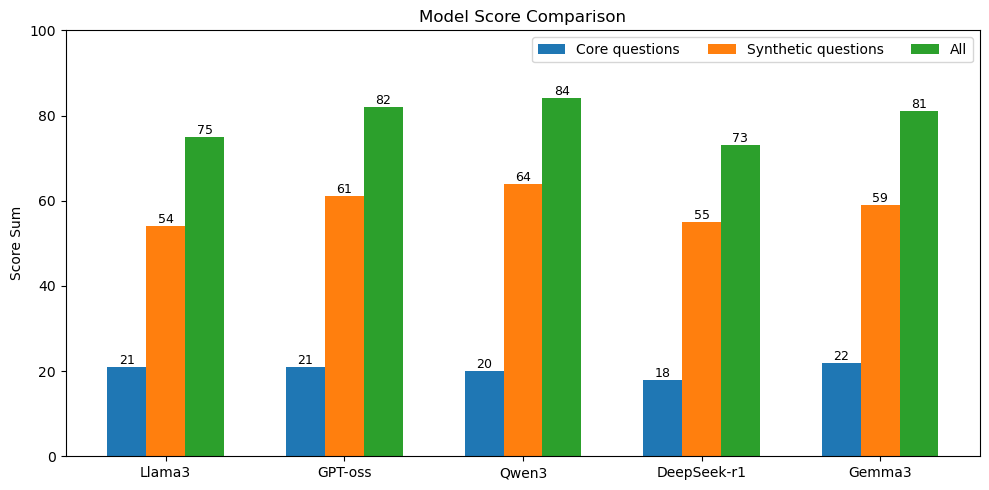

In [71]:
scores = qa_restored[['score_'+ col for col in ans_cols]].values
models = ['Llama3', 'GPT-oss', 'Qwen3', 'DeepSeek-r1', 'Gemma3']
nim_ids = ["meta/llama3-8b-instruct", "openai/gpt-oss-20b", "qwen3-next-80b-a3b-instruct", "deepseek-ai/deepseek-r1","google/gemma-3-1b-it"]

import matplotlib.pyplot as plt

core_scores = np.nansum(scores[:5], axis=0)
syntehtic_scores = np.nansum(scores[5:], axis=0)
all_scores = np.nansum(scores, axis=0)
print(core_scores)
print(syntehtic_scores)
print(all_scores)

# Stack into (models × 3)
vals = np.vstack([core_scores, syntehtic_scores, all_scores]).T   # shape = (5, 3)

n_models = len(models)
n_bars = 3

bar_width = 0.25
gap = 0.4   # gap between model groups

# x positions of model groups
group_x = np.arange(n_models) * (n_bars * bar_width + gap)

fig, ax = plt.subplots(figsize=(10,5))
labels = ["Core questions", "Synthetic questions", "All"]
for i in range(n_bars):
    bars = ax.bar(
        group_x + i * bar_width,
        vals[:, i],
        width=bar_width,
        label=labels[i]
    )
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.0f}",
            ha="center",
            va="bottom",
            fontsize=9
        )
        
ax.set_xticks(group_x + bar_width)
ax.set_xticklabels(models)

ax.set_ylabel("Score Sum")
ax.set_ylim([0, 100])
ax.set_title("Model Score Comparison")
ax.legend(ncol=3)

plt.tight_layout()
plt.show()

/var/folders/yv/lllpcq5d7g9cxbvg8bj3tg080000gn/T/ipykernel_22057/4011624304.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scores['No'] = ['Q'+str(i+1) for i in range(20)]


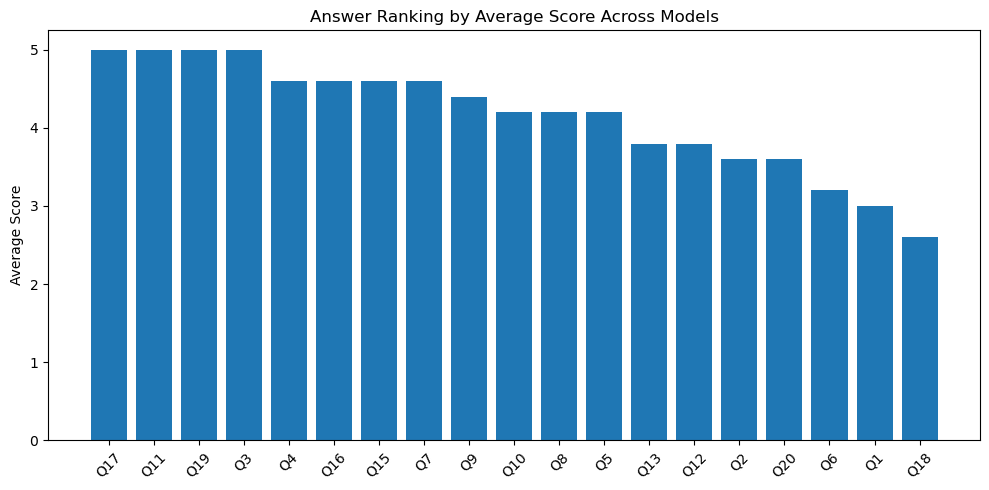

In [81]:
# rank questions by average answer scores 
scores = qa_restored[['score_'+ col for col in ans_cols]]
scores['No'] = ['Q'+str(i+1) for i in range(20)]
scores = scores.dropna()
scores_clr = scores[['score_'+ col for col in ans_cols]].values
labels = scores['No'].values

# Compute average score per question
avg_scores = scores_clr.mean(axis=1)

# Sort answers by average score (descending)
order = np.argsort(avg_scores)[::-1]

sorted_scores = avg_scores[order]

# X labels: Answer 1, Answer 2, ...
labels = labels[order]

fig, ax = plt.subplots(figsize=(10,5))

ax.bar(range(len(sorted_scores)), sorted_scores)

ax.set_xticks(range(len(sorted_scores)))
ax.set_xticklabels(labels, rotation=45)

ax.set_ylabel("Average Score")
ax.set_title("Answer Ranking by Average Score Across Models")

plt.tight_layout()
plt.show()


In [119]:
# Answer the synthetic questions using RAG chain
rag_answers = []
for i in range(num_questions):
    question = synth_questions[i]
    qa_pair = rag_chain.invoke(question)
    
    rag_answer = qa_pair.split('\n\n')[1]
    rag_answers += [rag_answer]
    print(f"QA Pair {i+1}", question, "", sep="\n")
    print(f"RAG {rag_answer}", "", sep='\n')
    

QA Pair 1
 Question: Which model, KGML-ag1 or KGML-ag2, performed better in capturing the magnitude and dynamics of N2O fluxes according to the research findings?

RAG Answer: According to the research findings, KGML-ag1 performed better in capturing the magnitude and dynamics of N2O fluxes. The document states that KGML-ag1 consistently provided the lowest RMSE (3.59–3.94 mgNm−2 d−1) and highest r2 (0.78–0.81) for N2O fluxes, slope, and curvature, indicating that it outperformed other pure ML models in capturing both the magnitude and dynamics of N2O flux. Additionally, the document mentions that KGML-ag1 had comparable uncertainties based on ensemble simulations, whereas KGML-ag2 presented slightly better mean scores for N2O flux predictions but worse scores for slope and curvature and larger uncertainties.

QA Pair 2
 Question: What is PyKGML and what is it used for?

RAG Answer: PyKGML is a Python library that facilitates the development of knowledge-guided machine learning (KGML) 